# Deliverable 3 — Stroke Risk Prediction: Experiments and Evaluation

This notebook reproduces the **Deliverable 3** machine learning workflow: stratified train/test split, four preprocessing dataset versions (V1–V4), cross-validated screening of candidate models, shortlisting, `GridSearchCV` hyperparameter tuning, and held-out test evaluation. All computation is delegated to [`Deliverable3_Experiments.py`](Deliverable3_Experiments.py) so that pipelines, metrics, and outputs remain identical to running the script.

**Prerequisites:** Python 3 with `numpy`, `pandas`, `scikit-learn`, `imbalanced-learn`, `matplotlib`, `seaborn`, `joblib`. Run the notebook with the working directory set to this folder (`deliverable3`) or to the repository root (the first code cell adjusts the path automatically).

**Reference for the written report:** Treat this notebook as the **canonical source** for Deliverable 3 metrics, plots, and JSON summaries. When copying into Word or LaTeX, use the **Report-ready tables** in the section below the raw `DataFrame` views, or copy directly from `tables/initial_cv_model_summary.csv` and `tables/initial_cv_version_summary.csv`. **ROC-AUC** must be taken from the column `roc_auc_mean` — it measures ranking quality and is **not** the same as balanced accuracy (do not copy one column into the other).

## Environment and imports

The experiment module configures `matplotlib` with the non-interactive **Agg** backend for file export; figures are saved under `figures/` and also displayed below using the saved PNG files.

In [1]:
import contextlib
import io
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.model_selection import StratifiedKFold, train_test_split

_cwd = Path.cwd().resolve()
_d3 = _cwd if (_cwd / "Deliverable3_Experiments.py").exists() else _cwd / "deliverable3"
if not (_d3 / "Deliverable3_Experiments.py").exists():
    raise FileNotFoundError(
        "Place the notebook in deliverable3/ or run Jupyter from the repo root so that "
        "Deliverable3_Experiments.py can be found."
    )
sys.path.insert(0, str(_d3))

from Deliverable3_Experiments import (
    CV_SPLITS,
    DATA_PATH,
    RANDOM_STATE,
    ROOT,
    TABLES_DIR,
    TEST_SIZE,
    build_candidate_models,
    build_preprocessor,
    ensure_dirs,
    get_param_grids,
    get_scorers,
    initial_experiments,
    plot_balanced_accuracy_heatmap,
    plot_initial_heatmap,
    plot_metric_bars,
    plot_roc_curves,
    plot_tuned_results,
    select_top_candidates,
    summarize_initial_results,
    tune_and_evaluate,
    load_data,
)

FIGURES_DIR = ROOT / "figures"
sns.set_theme(style="whitegrid")

## Data loading

The stroke dataset is loaded from `deliverable2/data/healthcare-dataset-stroke-data.csv`. Identifiers are dropped, duplicate rows removed, and a short summary records class balance and missingness.

In [2]:
ensure_dirs()

X, y, dataset_summary = load_data()
dataset_summary.to_csv(TABLES_DIR / "dataset_summary.csv", index=False)
display(dataset_summary)

,raw_rows,raw_columns,rows_after_dedup,columns_after_drop_id,duplicate_rows_removed,stroke_cases,non_stroke_cases,stroke_rate_pct,missing_bmi
0,5110,12,5110,11,0,249,4861,4.87,201


## Train / test split

A single **stratified** split preserves the minority stroke rate in both partitions; all tuning and cross-validation use the training set only. The held-out test set is used once for final metrics.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame(
    [
        {
            "train_rows": X_train.shape[0],
            "test_rows": X_test.shape[0],
            "train_stroke_rate_pct": round(100 * y_train.mean(), 2),
            "test_stroke_rate_pct": round(100 * y_test.mean(), 2),
        }
    ]
)
split_summary.to_csv(TABLES_DIR / "train_test_split_summary.csv", index=False)
display(split_summary)

,train_rows,test_rows,train_stroke_rate_pct,test_stroke_rate_pct
0,4088,1022,4.87,4.89


## Preprocessing: dataset versions V1–V4

Each version is an **imbalanced-learn** `Pipeline` prefix (plus classifier): **V1** imputes and one-hot encodes; **V2** adds standard scaling for numeric features; **V3** applies **SMOTE** inside each CV training fold; **V4** adds **PCA** (95% explained variance) after SMOTE. Steps are fitted only on training data within each fold, which avoids leakage.

In [4]:
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()

versions = [
    build_preprocessor("V1", num_features, cat_features),
    build_preprocessor("V2", num_features, cat_features),
    build_preprocessor("V3", num_features, cat_features),
    build_preprocessor("V4", num_features, cat_features),
]
versions_by_name = {v.name: v for v in versions}
pd.DataFrame(
    [{"name": v.name, "description": v.description} for v in versions]
)

,name,description
0,V1,Median numeric imputation + most-frequent cate...
1,V2,V1 plus standard scaling for numerical features.
2,V3,V2 plus SMOTE applied inside each training fold.
3,V4,V3 plus PCA retaining 95% explained variance.


## Model evaluation metrics

Cross-validation and `GridSearchCV` report **accuracy**, **balanced accuracy**, **precision**, **recall**, **weighted F1**, and **ROC-AUC**. The tuning refit criterion is **balanced accuracy** (stroke is the positive class). Test metrics include per-class counts from the confusion matrix.

In [5]:
pd.Series({k: str(v) for k, v in get_scorers().items()}, name="scorer")

accuracy                                                      accuracy
balanced_accuracy                                    balanced_accuracy
precision            make_scorer(precision_score, response_method='...
recall               make_scorer(recall_score, response_method='pre...
f1_weighted          make_scorer(f1_score, response_method='predict...
roc_auc                                                        roc_auc
Name: scorer, dtype: str

## Candidate models

Candidate classifiers are logistic regression, k-NN, random forest, SVM (with `probability=True` for ROC-AUC), and AdaBoost. Each is wrapped with a chosen dataset version using `build_pipeline` in the experiment module.

In [6]:
models = build_candidate_models()
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
list(models.keys())

['LogisticRegression', 'KNN', 'RandomForest', 'SVM', 'AdaBoost']

## Pipeline definition

End-to-end pipelines concatenate a **dataset version** (preprocessing, and optionally SMOTE and PCA) with a **classifier**, implemented as `ImbPipeline` in `Deliverable3_Experiments.build_pipeline`. Hyperparameter grids for `GridSearchCV` use the `classifier__` prefix on estimator parameters. The grids below are returned by `get_param_grids()` and are identical to those used in the script.

In [7]:
param_grids = get_param_grids()
for name, grids in param_grids.items():
    display(name, grids)

'LogisticRegression'

[{'classifier__solver': ['liblinear', 'lbfgs'],
  'classifier__C': [0.1, 1.0, 5.0, 10.0],
  'classifier__class_weight': [None, 'balanced']}]

'KNN'

[{'classifier__n_neighbors': [5, 9, 15, 21],
  'classifier__weights': ['uniform', 'distance'],
  'classifier__metric': ['minkowski', 'manhattan']}]

'RandomForest'

[{'classifier__n_estimators': [200, 400],
  'classifier__max_depth': [None, 10, 20],
  'classifier__min_samples_split': [2, 5],
  'classifier__min_samples_leaf': [1, 2],
  'classifier__class_weight': [None, 'balanced']}]

'SVM'

[{'classifier__kernel': ['linear', 'rbf'],
  'classifier__C': [0.5, 1.0, 5.0],
  'classifier__gamma': ['scale', 'auto'],
  'classifier__class_weight': [None, 'balanced']}]

'AdaBoost'

[{'classifier__n_estimators': [50, 100, 200],
  'classifier__learning_rate': [0.5, 1.0, 1.5]}]

## Initial cross-validated experimentation

Every combination of dataset version and model is evaluated with **5-fold stratified cross-validation** on the training set. Mean and standard deviation per metric are recorded for each fold.

In [8]:
_buf = io.StringIO()
with contextlib.redirect_stdout(_buf):
    results_df = initial_experiments(X_train, y_train, versions, models, cv)
results_df.to_csv(TABLES_DIR / "initial_cv_results.csv", index=False)
display(results_df)

,dataset_version,version_description,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_weighted_mean,f1_weighted_std,roc_auc_mean,roc_auc_std
15,V4,V3 plus PCA retaining 95% explained variance.,LogisticRegression,0.738503,0.012996,0.762448,0.010216,0.132814,0.006407,0.788974,0.012927,0.812627,0.009070,0.833038,0.011152
19,V4,V3 plus PCA retaining 95% explained variance.,AdaBoost,0.687370,0.019646,0.759483,0.038319,0.118540,0.012782,0.839359,0.067145,0.776096,0.014168,0.810834,0.021968
10,V3,V2 plus SMOTE applied inside each training fold.,LogisticRegression,0.745596,0.015895,0.754256,0.030639,0.133134,0.013232,0.763846,0.051627,0.817481,0.010988,0.837637,0.012996
14,V3,V2 plus SMOTE applied inside each training fold.,AdaBoost,0.738502,0.018812,0.719505,0.024858,0.121230,0.008453,0.698462,0.058731,0.812323,0.012937,0.801132,0.017540
18,V4,V3 plus PCA retaining 95% explained variance.,SVM,0.779842,0.016031,0.676949,0.036181,0.120786,0.009626,0.562949,0.088553,0.839468,0.010021,0.776376,0.013204
13,V3,V2 plus SMOTE applied inside each training fold.,SVM,0.789625,0.010119,0.667671,0.035897,0.121062,0.012247,0.532564,0.080796,0.845710,0.006028,0.772494,0.015432
16,V4,V3 plus PCA retaining 95% explained variance.,KNN,0.813847,0.016805,0.618168,0.042185,0.110986,0.022165,0.401410,0.085917,0.859923,0.010454,0.661749,0.022001
11,V3,V2 plus SMOTE applied inside each training fold.,KNN,0.810420,0.014760,0.595024,0.039453,0.099309,0.022271,0.356410,0.074013,0.857272,0.009504,0.665077,0.037756
17,V4,V3 plus PCA retaining 95% explained variance.,RandomForest,0.895551,0.006091,0.554073,0.022360,0.117108,0.025215,0.175769,0.046286,0.905246,0.003977,0.776519,0.029407
12,V3,V2 plus SMOTE applied inside each training fold.,RandomForest,0.924901,0.004477,0.512265,0.011454,0.086205,0.032654,0.055128,0.020687,0.917371,0.002732,0.789080,0.010656


## Aggregated summaries (initial CV)

Results are aggregated by **model** and by **dataset version** to support shortlisting.

In [9]:
model_summary, version_summary = summarize_initial_results(results_df)
model_summary.to_csv(TABLES_DIR / "initial_cv_model_summary.csv", index=False)
version_summary.to_csv(TABLES_DIR / "initial_cv_version_summary.csv", index=False)
display(model_summary)
display(version_summary)

,model,accuracy_mean,balanced_accuracy_mean,precision_mean,recall_mean,f1_weighted_mean,roc_auc_mean
2,LogisticRegression,0.846563,0.629112,0.066487,0.388205,0.871260,0.837518
0,AdaBoost,0.832128,0.619747,0.059943,0.384455,0.860899,0.818874
4,SVM,0.868027,0.586155,0.060462,0.273878,0.885089,0.706843
1,KNN,0.879465,0.557509,0.121383,0.200833,0.892884,0.654686
3,RandomForest,0.930774,0.518956,0.184161,0.062724,0.919909,0.793121


,dataset_version,version_description,accuracy_mean,balanced_accuracy_mean,precision_mean,recall_mean,f1_weighted_mean,roc_auc_mean
3,V4,V3 plus PCA retaining 95% explained variance.,0.783023,0.674224,0.120047,0.553692,0.838672,0.771703
2,V3,V2 plus SMOTE applied inside each training fold.,0.801809,0.649744,0.112188,0.481282,0.850031,0.773084
0,V1,Median numeric imputation + most-frequent cate...,0.950294,0.502819,0.079048,0.007077,0.927659,0.766028
1,V2,V1 plus standard scaling for numerical features.,0.950441,0.502396,0.082667,0.006026,0.927670,0.738018


### Report-ready tables (initial CV)

Use these formatted tables when pasting into the thesis or report. Values are **CV means** (5-fold), rounded to four decimals. **ROC-AUC** is the mean `roc_auc` score across folds (`roc_auc_mean` in the CSV)—distinct from balanced accuracy.


In [19]:
from IPython.display import Markdown

_report_rename = {
    "accuracy_mean": "Accuracy",
    "balanced_accuracy_mean": "Balanced accuracy",
    "precision_mean": "Precision",
    "recall_mean": "Recall",
    "f1_weighted_mean": "Weighted F1",
    "roc_auc_mean": "ROC-AUC",
}

def _report_round(df: pd.DataFrame, rename: dict) -> pd.DataFrame:
    out = df.rename(columns=rename)
    num = out.select_dtypes(include=[np.number]).columns
    out[num] = out[num].round(4)
    return out

report_by_model = _report_round(model_summary, {"model": "Model", **_report_rename})
display(Markdown("#### Initial cross-validation — by model"))
display(report_by_model)

ver_rename = {"dataset_version": "Dataset version", **_report_rename}
report_by_version = _report_round(version_summary, ver_rename).drop(
    columns=["version_description"], errors="ignore"
)
display(Markdown("#### Initial cross-validation — by dataset version"))
display(report_by_version)


#### Initial cross-validation — by model

,Model,Accuracy,Balanced accuracy,Precision,Recall,Weighted F1,ROC-AUC
2,LogisticRegression,0.8466,0.6291,0.0665,0.3882,0.8713,0.8375
0,AdaBoost,0.8321,0.6197,0.0599,0.3845,0.8609,0.8189
4,SVM,0.8680,0.5862,0.0605,0.2739,0.8851,0.7068
1,KNN,0.8795,0.5575,0.1214,0.2008,0.8929,0.6547
3,RandomForest,0.9308,0.5190,0.1842,0.0627,0.9199,0.7931


#### Initial cross-validation — by dataset version

,Dataset version,Accuracy,Balanced accuracy,Precision,Recall,Weighted F1,ROC-AUC
3,V4,0.7830,0.6742,0.1200,0.5537,0.8387,0.7717
2,V3,0.8018,0.6497,0.1122,0.4813,0.8500,0.7731
0,V1,0.9503,0.5028,0.0790,0.0071,0.9277,0.7660
1,V2,0.9504,0.5024,0.0827,0.0060,0.9277,0.7380


## Initial CV visualisations

Heatmaps and bar charts are written to `figures/` and shown below.

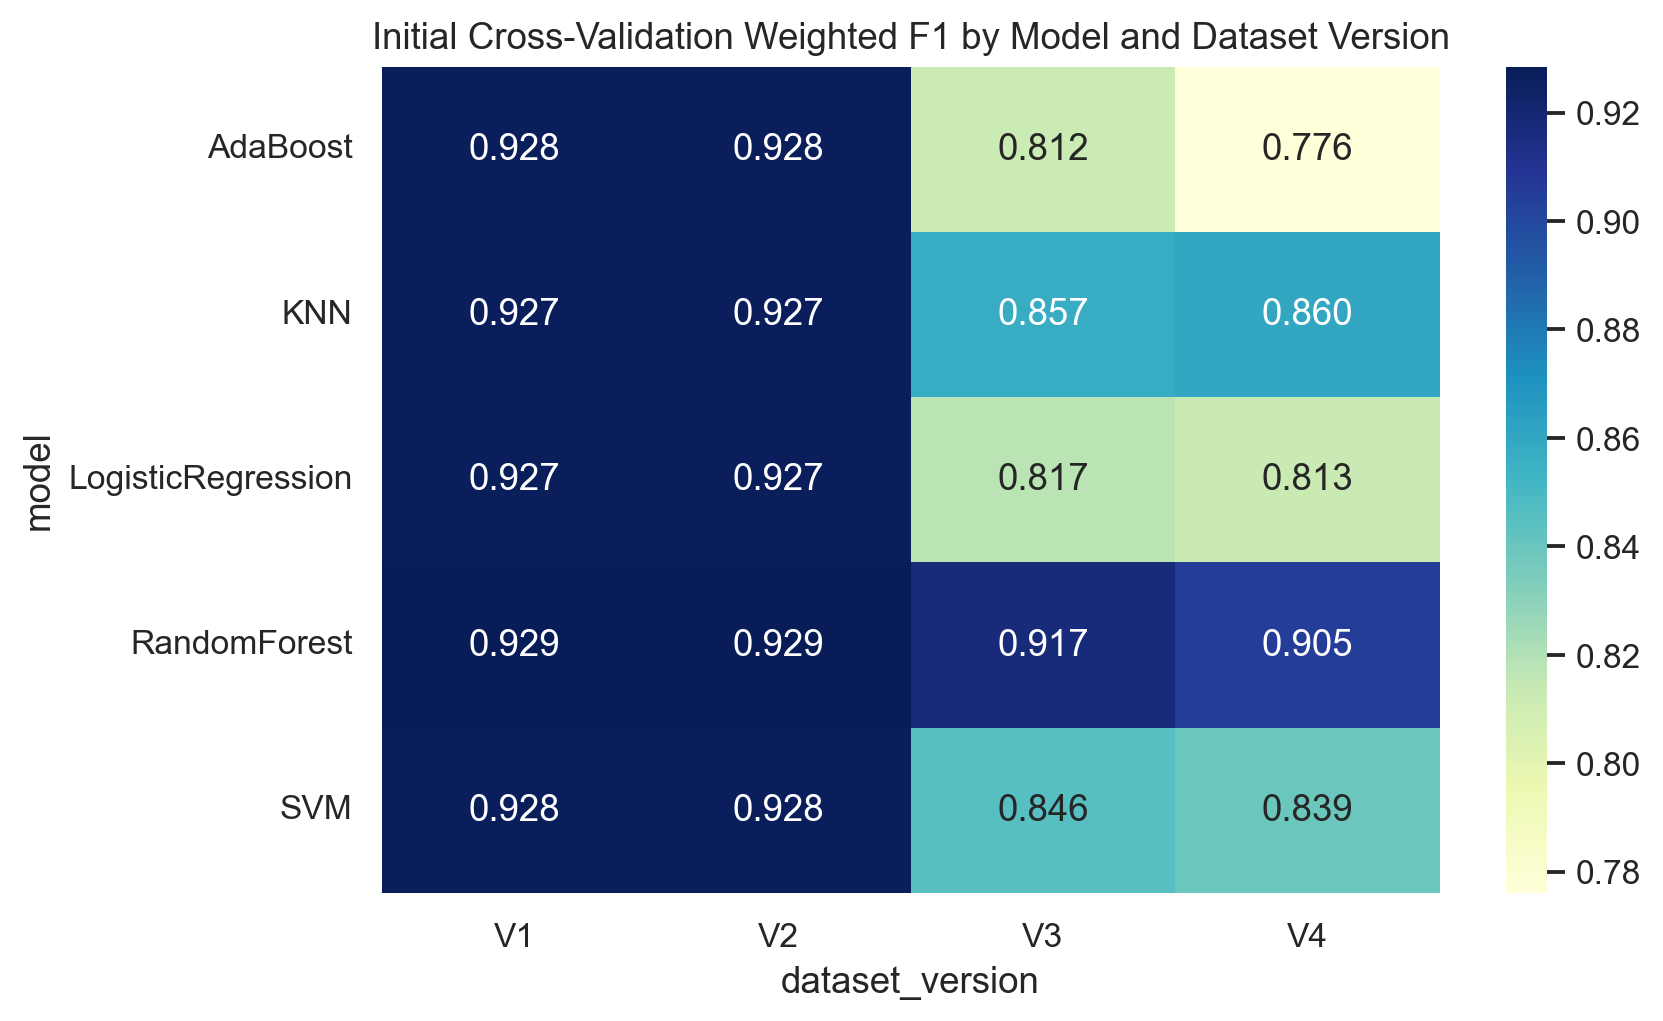

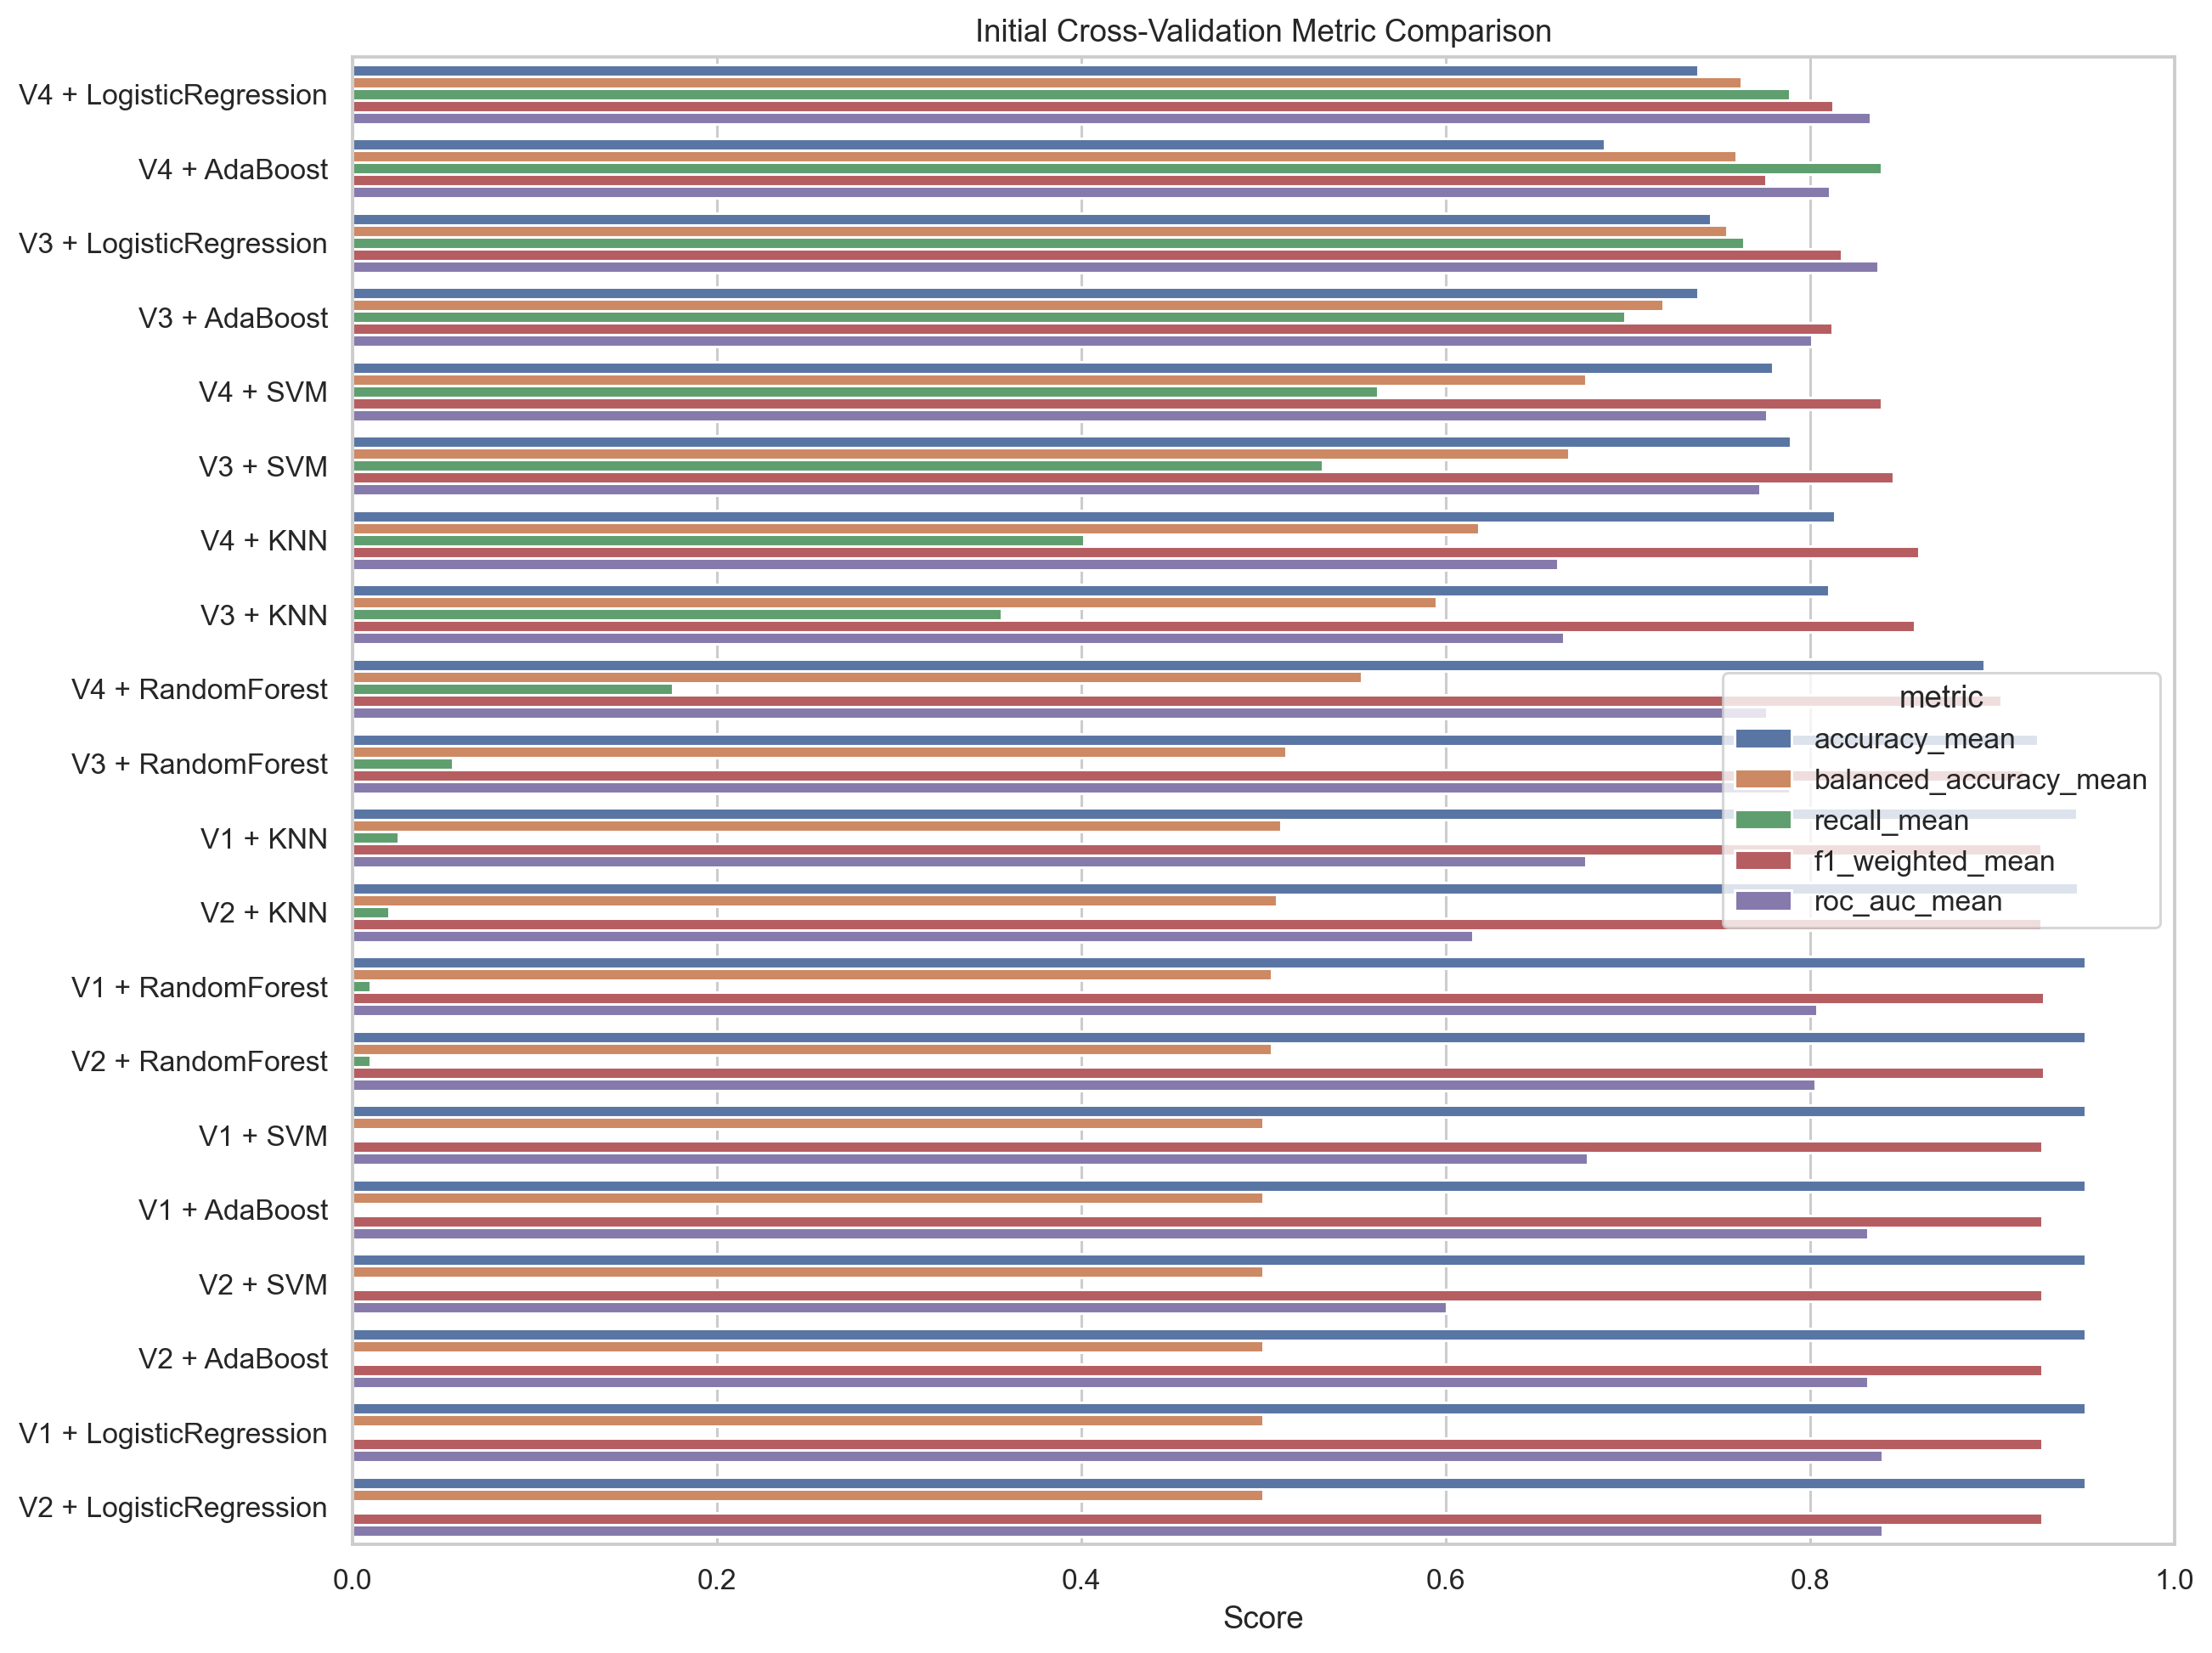

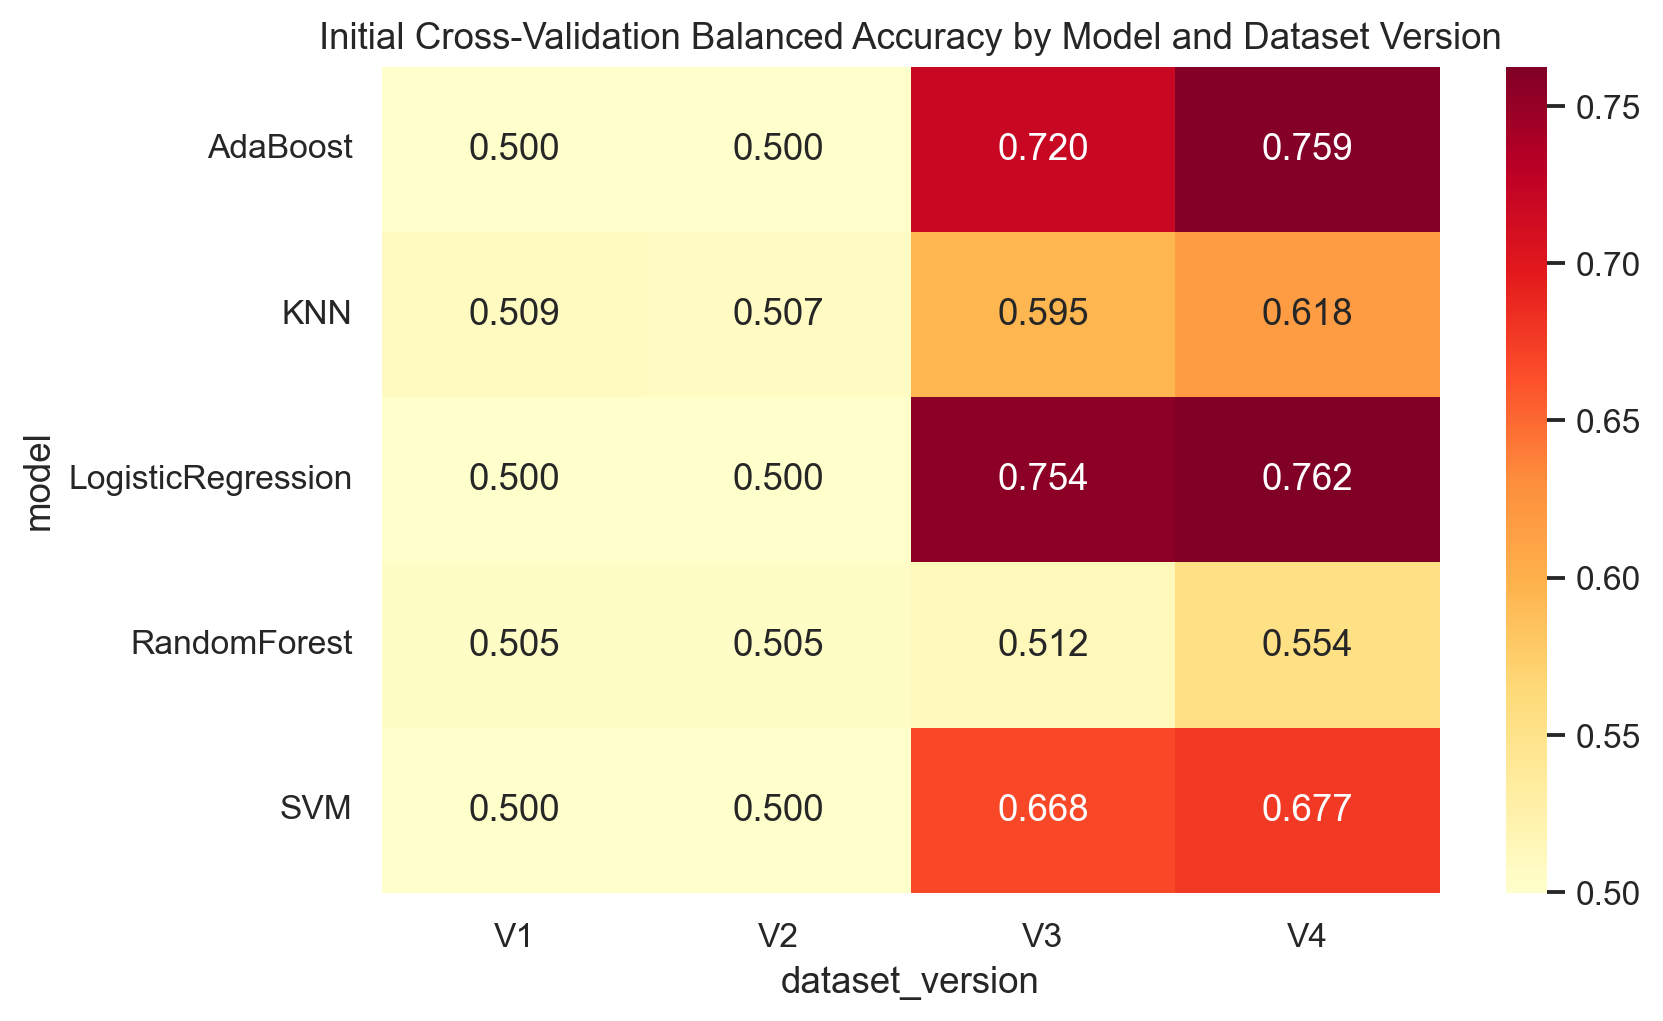

In [10]:
plot_initial_heatmap(results_df)
plot_metric_bars(results_df)
plot_balanced_accuracy_heatmap(results_df)

display(Image(filename=str(FIGURES_DIR / "initial_cv_f1_heatmap.png")))
display(Image(filename=str(FIGURES_DIR / "initial_cv_metric_bars.png")))
display(Image(filename=str(FIGURES_DIR / "initial_cv_balanced_accuracy_heatmap.png")))

## Model and version selection

The top **two** models and top **two** dataset versions (by aggregated CV means) proceed to hyperparameter tuning. Combinations with high CV ROC-AUC but **zero recall** at the default threshold are documented in `selection_summary.json` as evidence of the need for SMOTE in V3/V4.

In [11]:
selected_models, selected_versions = select_top_candidates(model_summary, version_summary)

threshold_collapse = results_df[
    (results_df["recall_mean"] == 0.0) & (results_df["roc_auc_mean"] >= 0.75)
][["dataset_version", "model", "roc_auc_mean", "recall_mean", "balanced_accuracy_mean"]].to_dict(
    orient="records"
)

selection_summary = {
    "selected_models": selected_models,
    "selected_versions": selected_versions,
    "insight_threshold_collapse": {
        "description": (
            "These model+version combinations achieve a high CV ROC-AUC (good probabilistic "
            "ranking) yet recall = 0.0 at the default 0.5 threshold (always predict no-stroke). "
            "This confirms that SMOTE is necessary to shift the decision boundary toward the "
            "minority class; AUC alone is insufficient to detect strokes without rebalancing."
        ),
        "affected_combinations": threshold_collapse,
    },
}
(TABLES_DIR / "selection_summary.json").write_text(
    json.dumps(selection_summary, indent=2), encoding="utf-8"
)
display(pd.Series({"selected_models": selected_models, "selected_versions": selected_versions}))
display(selection_summary)

selected_models      [LogisticRegression, AdaBoost]
selected_versions                          [V4, V3]
dtype: object

{'selected_models': ['LogisticRegression', 'AdaBoost'],
 'selected_versions': ['V4', 'V3'],
 'insight_threshold_collapse': {'description': 'These model+version combinations achieve a high CV ROC-AUC (good probabilistic ranking) yet recall = 0.0 at the default 0.5 threshold (always predict no-stroke). This confirms that SMOTE is necessary to shift the decision boundary toward the minority class; AUC alone is insufficient to detect strokes without rebalancing.',
  'affected_combinations': [{'dataset_version': 'V1',
    'model': 'AdaBoost',
    'roc_auc_mean': 0.8317643519603675,
    'recall_mean': 0.0,
    'balanced_accuracy_mean': 0.5},
   {'dataset_version': 'V2',
    'model': 'AdaBoost',
    'roc_auc_mean': 0.8317643519603675,
    'recall_mean': 0.0,
    'balanced_accuracy_mean': 0.5},
   {'dataset_version': 'V1',
    'model': 'LogisticRegression',
    'roc_auc_mean': 0.8397205270470052,
    'recall_mean': 0.0,
    'balanced_accuracy_mean': 0.49987146529562987},
   {'dataset_version':

## Hyperparameter tuning (GridSearchCV)

For each shortlisted **model × dataset version** pair, **`GridSearchCV`** searches the predefined parameter grids in `Deliverable3_Experiments.get_param_grids()`, using the same stratified 5-fold CV and **refit on balanced accuracy**. The best estimator is evaluated on the held-out test set; models are saved under `models/`.

In [12]:
_buf = io.StringIO()
with contextlib.redirect_stdout(_buf):
    tuned_df, artifact_paths, finalist_estimators = tune_and_evaluate(
        X_train,
        y_train,
        X_test,
        y_test,
        versions_by_name,
        models,
        selected_models,
        selected_versions,
        cv,
    )
tuned_df.to_csv(TABLES_DIR / "tuned_model_results.csv", index=False)
display(tuned_df)

,dataset_version,model,combo,best_cv_balanced_accuracy,best_cv_balanced_accuracy_std,best_cv_recall,best_cv_recall_std,best_cv_roc_auc,best_cv_precision,best_cv_weighted_f1,...,roc_auc,tn,fp,fn,tp,stroke_precision_classification_report,stroke_recall_classification_report,stroke_f1_classification_report,pca_n_components,pca_total_variance_retained
0,V4,LogisticRegression,V4_LogisticRegression,0.762706,0.009338,0.788974,0.011563,0.832934,0.133047,0.812967,...,0.844403,729,243,10,40,0.141343,0.80,0.240240,11.0,0.9674
2,V3,LogisticRegression,V3_LogisticRegression,0.756499,0.027097,0.768846,0.042939,0.838363,0.133745,0.817322,...,0.844300,728,244,10,40,0.140845,0.80,0.239521,NaN,NaN
3,V3,AdaBoost,V3_AdaBoost,0.763911,0.023683,0.844359,0.036238,0.819025,0.120476,0.778937,...,0.833673,676,296,8,42,0.124260,0.84,0.216495,NaN,NaN
1,V4,AdaBoost,V4_AdaBoost,0.763622,0.031247,0.819359,0.055056,0.807535,0.126263,0.794725,...,0.829187,706,266,10,40,0.130719,0.80,0.224719,11.0,0.9674


## Tuned models: test metrics and ROC curves

Bar charts summarise held-out test metrics; ROC curves compare finalists on the same test labels.

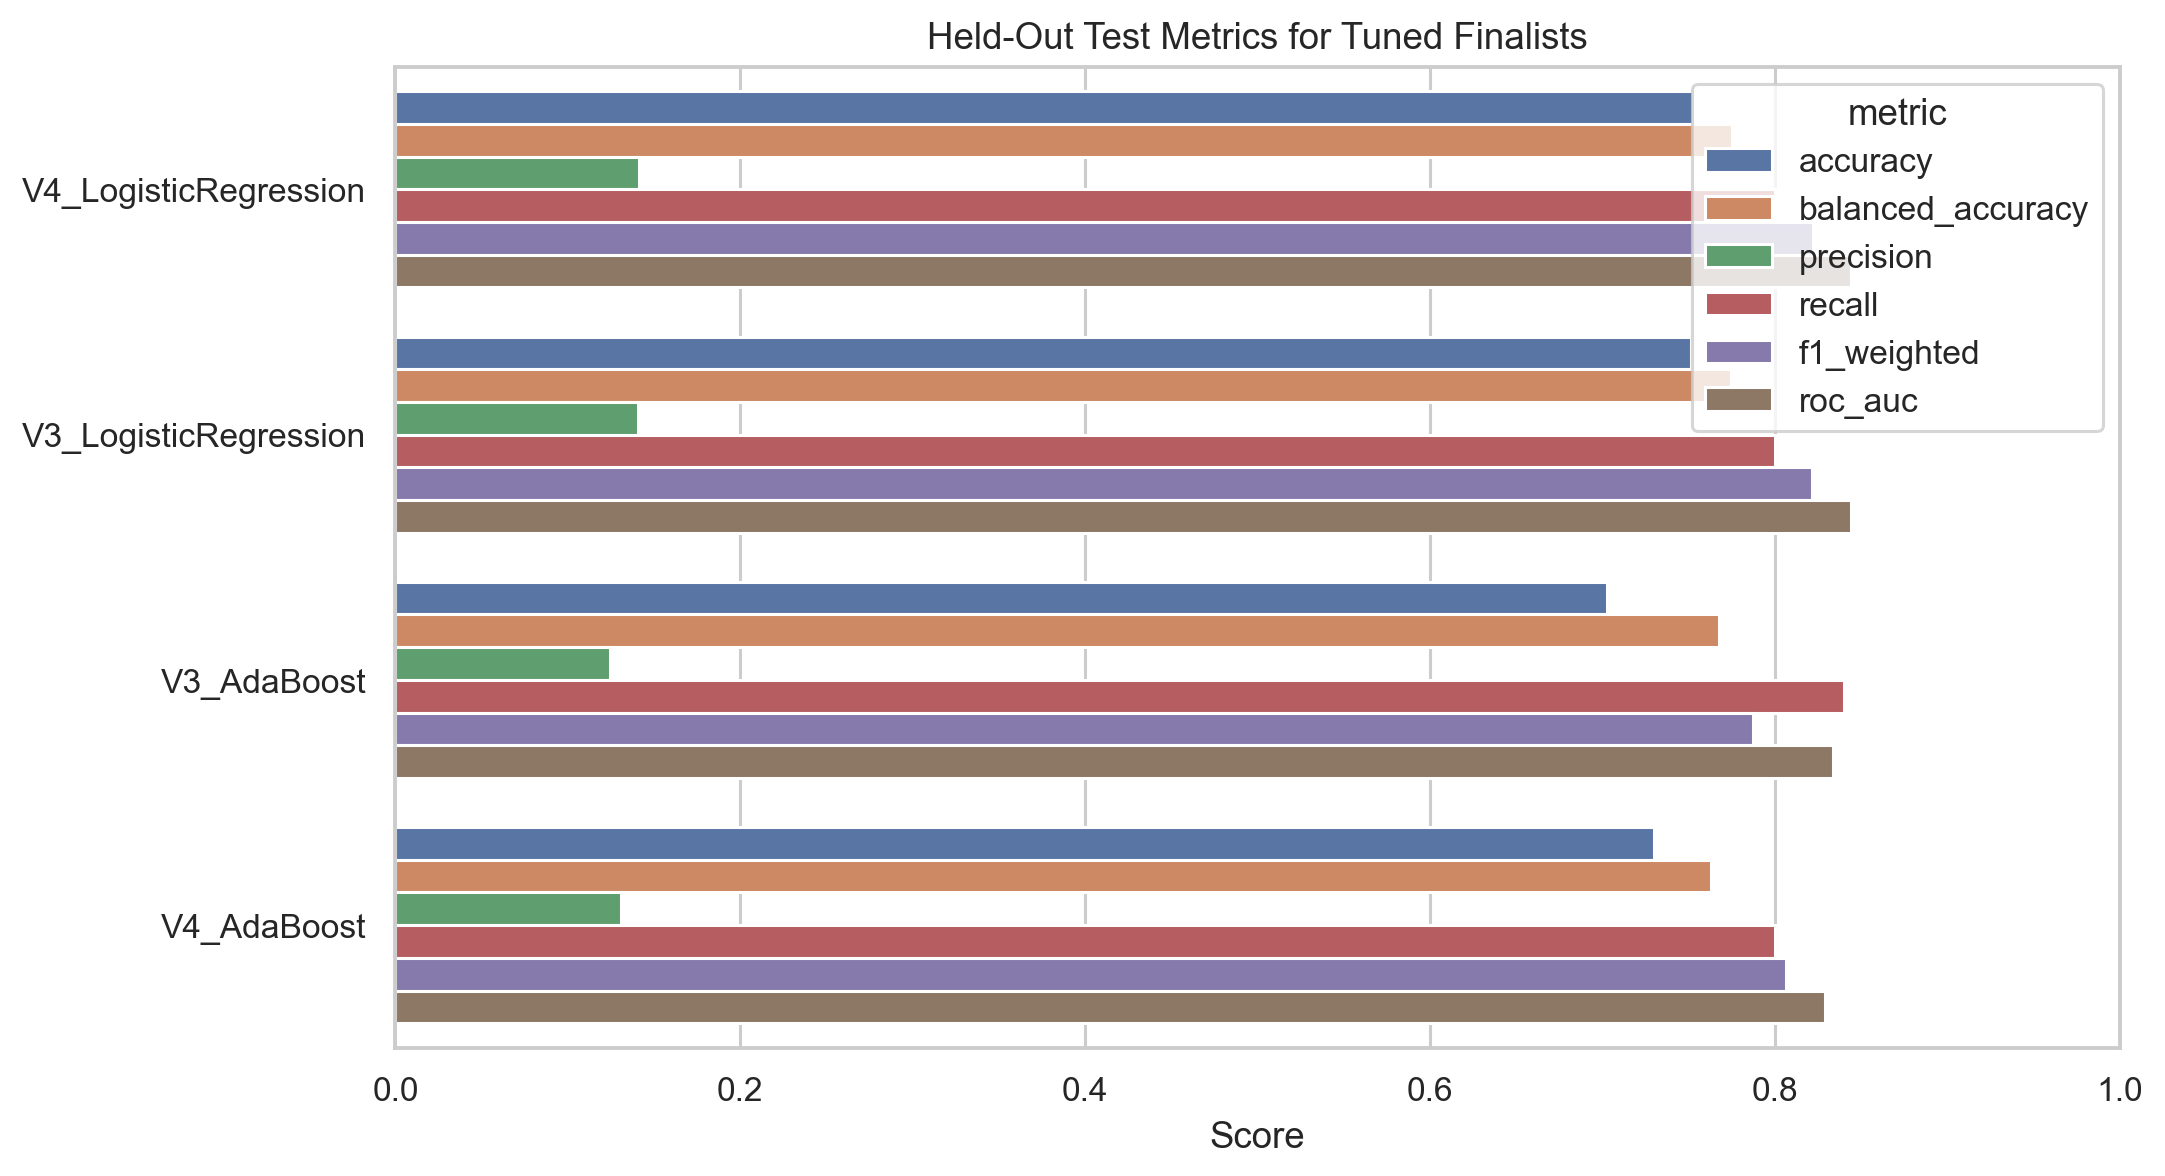

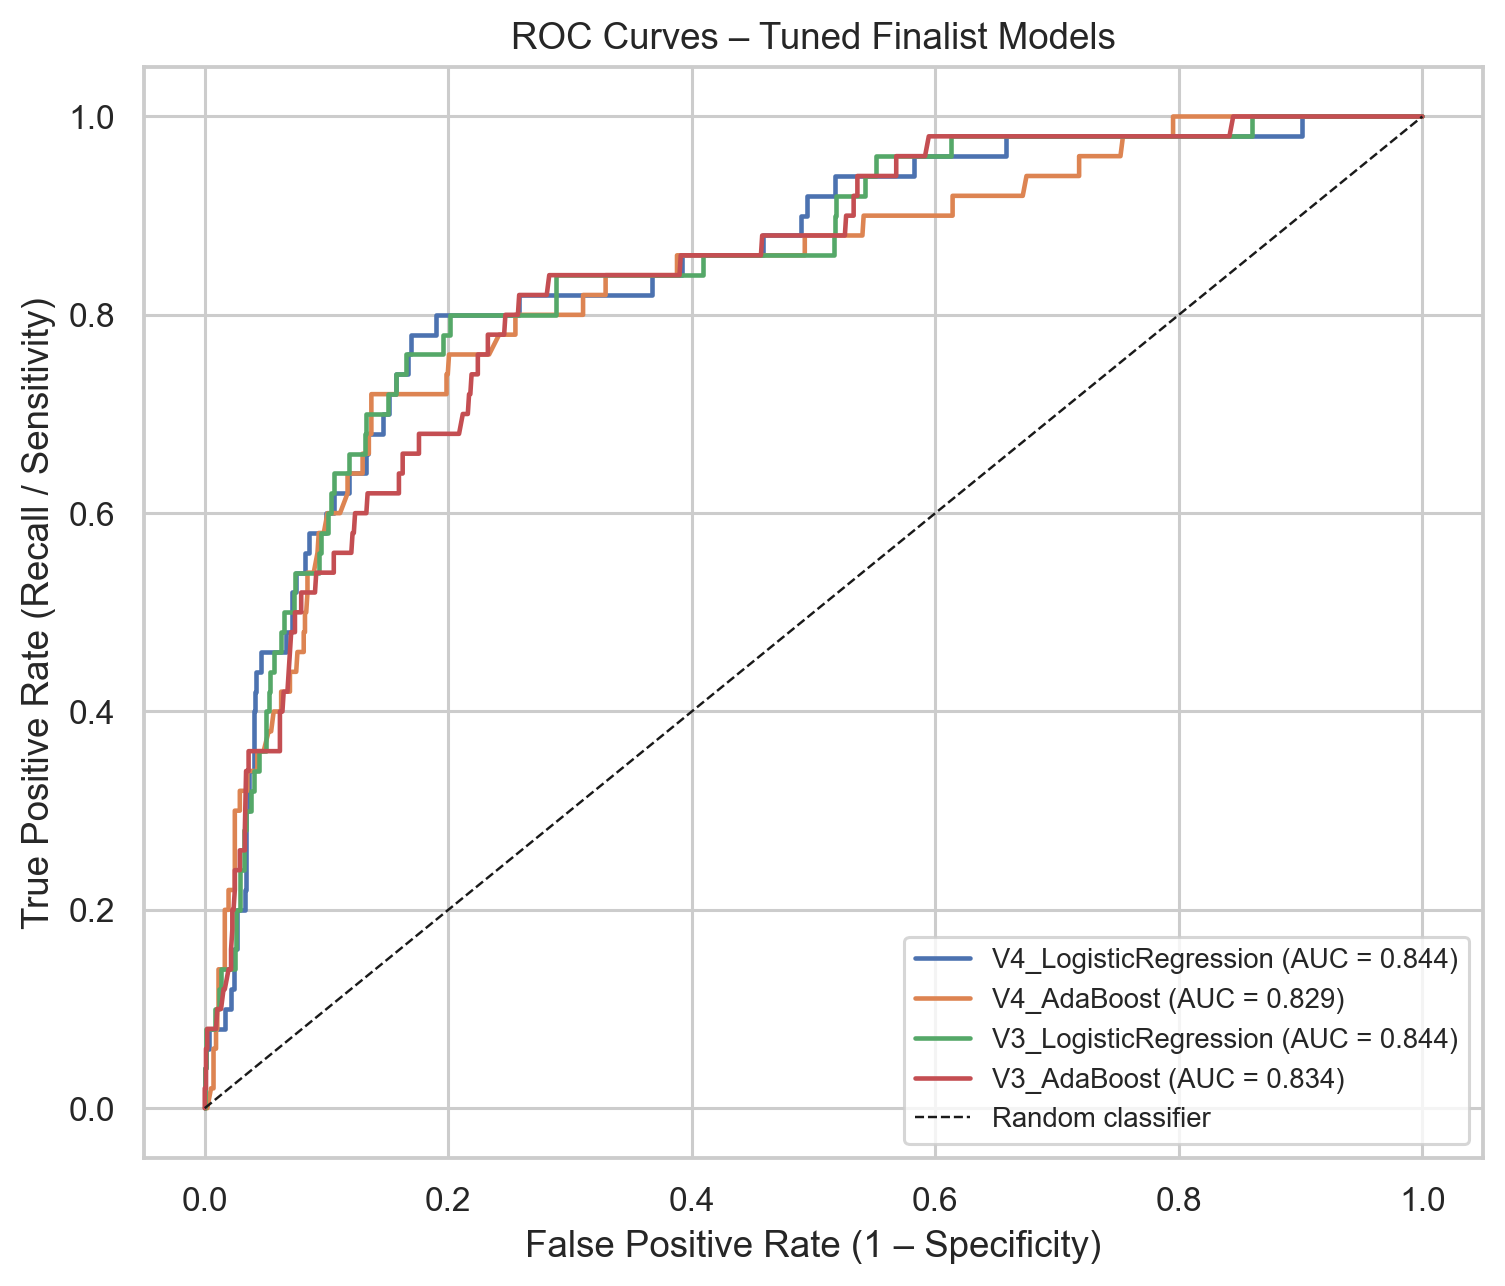

In [13]:
plot_tuned_results(tuned_df)
plot_roc_curves(finalist_estimators, X_test, y_test)

display(Image(filename=str(FIGURES_DIR / "tuned_test_metric_bars.png")))
display(Image(filename=str(FIGURES_DIR / "roc_curves_finalists.png")))

## Confusion matrices (finalists)

Confusion matrices are saved per finalist combination; they are displayed below for inclusion in reports.

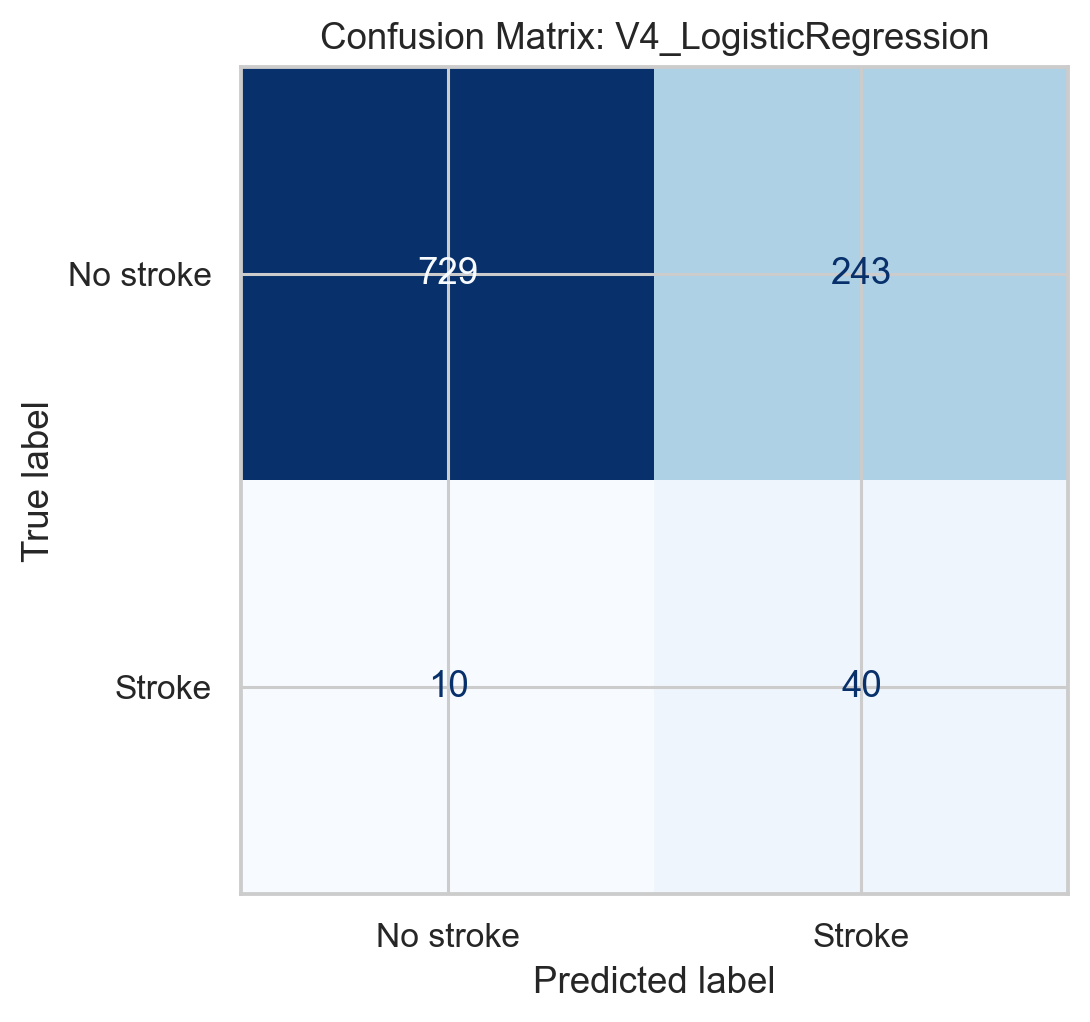

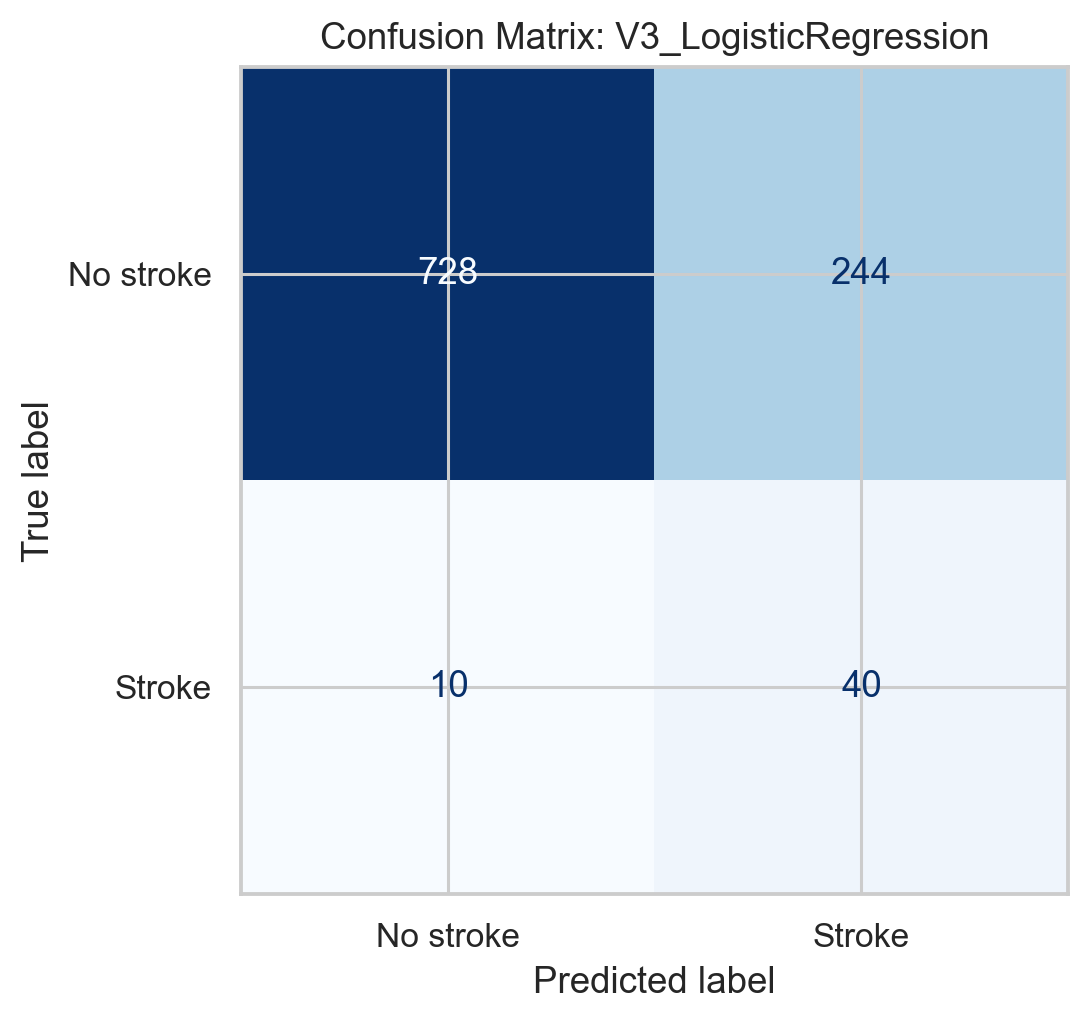

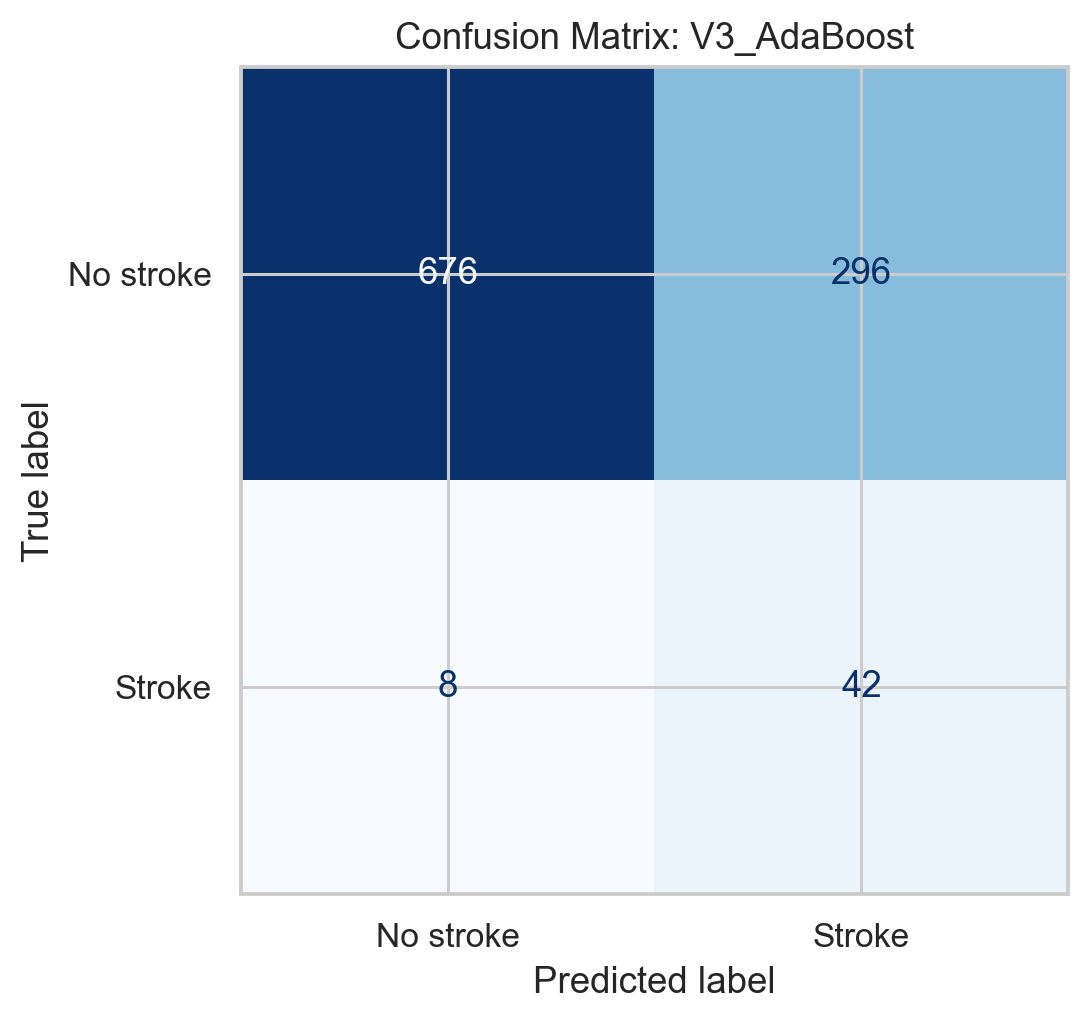

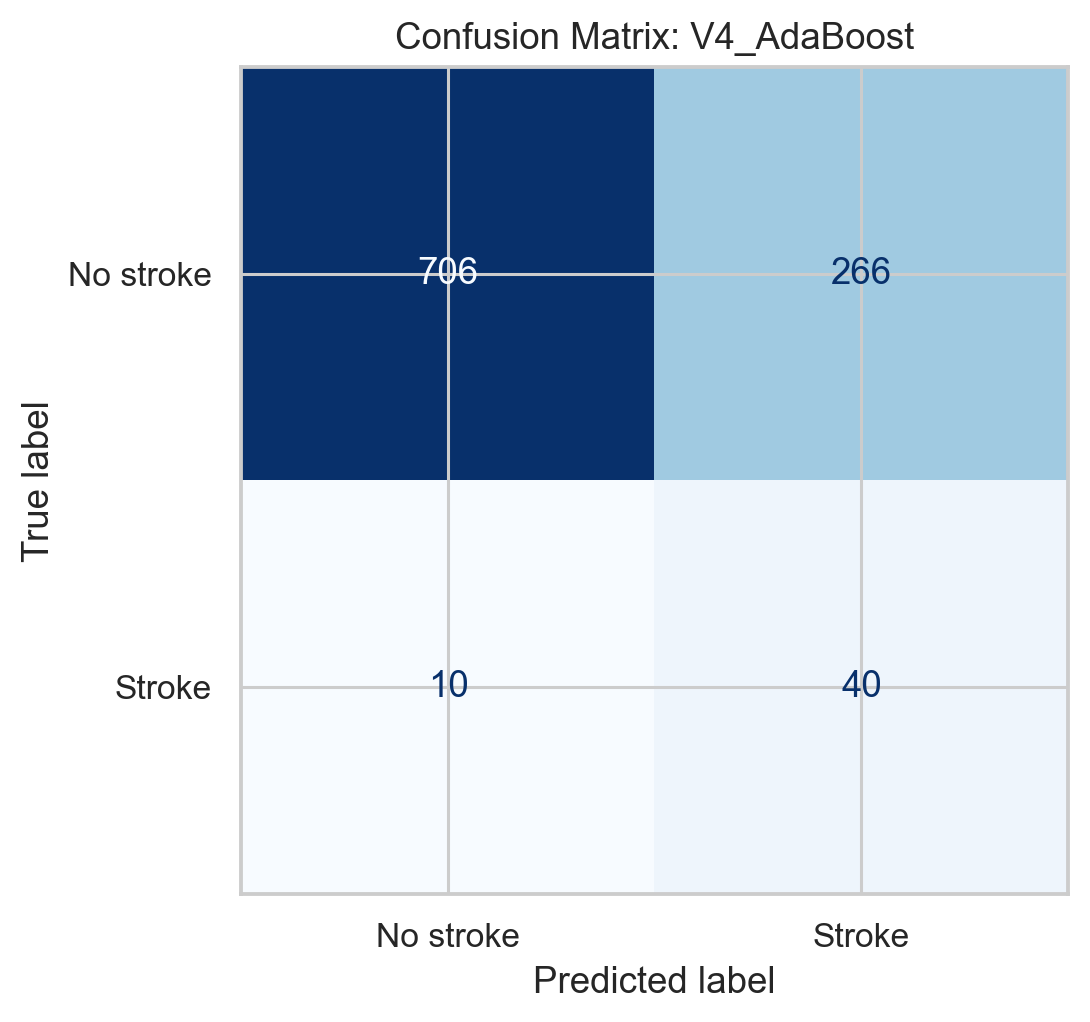

In [14]:
for combo in tuned_df["combo"]:
    safe = combo.lower().replace(" ", "_")
    p = FIGURES_DIR / f"confusion_matrix_{safe}.png"
    if p.exists():
        display(Image(filename=str(p)))

## Final evaluation: best model and JSON summary

The best row is the first row of `tuned_df` after sorting by balanced accuracy, recall, macro F1, and weighted F1 (same order as in the script). A JSON summary mirrors `tables/final_summary.json`.

In [16]:
best_row = tuned_df.iloc[0].to_dict()
tp_count = int(best_row["tp"])
fn_count = int(best_row["fn"])
fp_count = int(best_row["fp"])
tn_count = int(best_row["tn"])

final_summary = {
    "data_path": str(DATA_PATH.relative_to(ROOT.parent)),
    "random_state": RANDOM_STATE,
    "cv_splits": CV_SPLITS,
    "selected_models": selected_models,
    "selected_versions": selected_versions,
    "best_model_combo": best_row["combo"],
    "best_model_path": str(Path(artifact_paths[best_row["combo"]]).relative_to(ROOT.parent)),
    "best_model_metrics": {
        "accuracy": round(float(best_row["accuracy"]), 4),
        "balanced_accuracy": round(float(best_row["balanced_accuracy"]), 4),
        "precision": round(float(best_row["precision"]), 4),
        "recall": round(float(best_row["recall"]), 4),
        "f1_weighted": round(float(best_row["f1_weighted"]), 4),
        "f1_macro": round(float(best_row["f1_macro"]), 4),
        "roc_auc": round(float(best_row["roc_auc"]), 4),
    },
    "best_model_params": json.loads(best_row["best_params"]),
    "best_model_interpretation": {
        "tp": tp_count,
        "fn": fn_count,
        "fp": fp_count,
        "tn": tn_count,
        "note": (
            f"Of {tp_count + fn_count} actual stroke cases in the held-out test set, "
            f"{tp_count} were correctly flagged (TP) and {fn_count} were missed (FN — false negatives). "
            f"{fp_count} non-stroke patients were incorrectly flagged as high-risk (FP — false positives). "
            "In a population screening context, minimising false negatives is the primary goal: "
            "a missed stroke (FN) carries a far higher clinical cost than an unnecessary follow-up (FP)."
        ),
    },
    "design_rationale": {
        "low_precision_is_expected": (
            f"Precision of {round(float(best_row['precision']), 3)} is low by design. "
            f"The model flags {fp_count} false positives alongside {tp_count} true positives "
            "because it was optimised for recall (sensitivity) rather than precision. "
            "In a population-level screening tool this is the correct tradeoff: the goal is "
            "to minimise missed strokes and refer borderline cases for clinical follow-up, "
            "not to achieve high precision at the cost of undetected events."
        ),
        "metric_selection_rationale": (
            "Balanced accuracy and recall were chosen as primary selection criteria because "
            "raw accuracy is misleading on this dataset (~95% accuracy is achievable by "
            "predicting no-stroke for every patient). Balanced accuracy penalises both "
            "false negatives and false positives equally, while recall directly measures "
            "the fraction of actual stroke cases detected — the clinically critical quantity."
        ),
    },
}
(TABLES_DIR / "final_summary.json").write_text(json.dumps(final_summary, indent=2), encoding="utf-8")
display(final_summary)

{'data_path': 'deliverable2/data/healthcare-dataset-stroke-data.csv',
 'random_state': 42,
 'cv_splits': 5,
 'selected_models': ['LogisticRegression', 'AdaBoost'],
 'selected_versions': ['V4', 'V3'],
 'best_model_combo': 'V4_LogisticRegression',
 'best_model_path': 'deliverable3/models/V4_LogisticRegression.joblib',
 'best_model_metrics': {'accuracy': 0.7524,
  'balanced_accuracy': 0.775,
  'precision': 0.1413,
  'recall': 0.8,
  'f1_weighted': 0.8222,
  'f1_macro': 0.5462,
  'roc_auc': 0.8444},
 'best_model_params': {'classifier__C': 5.0,
  'classifier__class_weight': None,
  'classifier__solver': 'lbfgs'},
 'best_model_interpretation': {'tp': 40,
  'fn': 10,
  'fp': 243,
  'tn': 729,
  'note': 'Of 50 actual stroke cases in the held-out test set, 40 were correctly flagged (TP) and 10 were missed (FN — false negatives). 243 non-stroke patients were incorrectly flagged as high-risk (FP — false positives). In a population screening context, minimising false negatives is the primary goal: